# Targets Distribution

y_HY3 shape: (935, 1)
y_HY3_Augmentation shape: (965, 1)
y_HY43 shape: (957, 1)


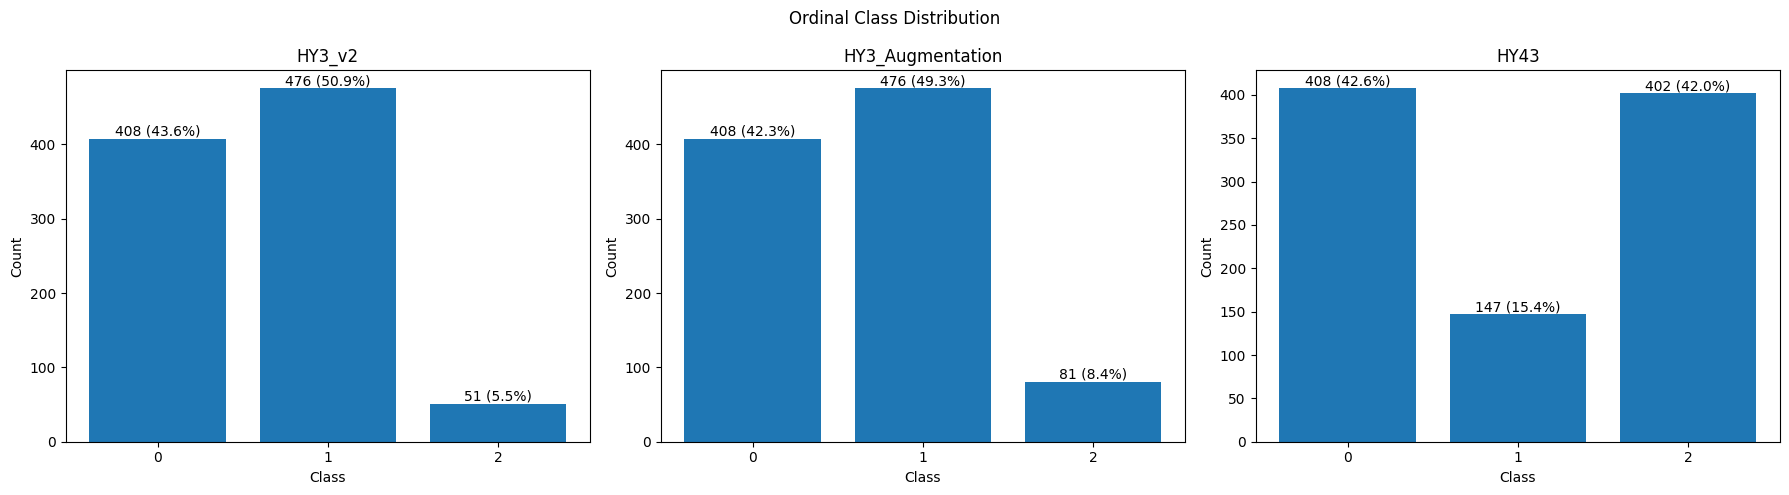

In [69]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_HY3_v2 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_final.csv", index_col=0)
y_HY3_v2_sampled = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY3_v2_Sampled_HY3.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY43_v2_final.csv", index_col=0)
print("y_HY3 shape:", y_HY3_v2.shape)
print("y_HY3_Augmentation shape:", y_HY3_v2_sampled.shape)
print("y_HY43 shape:", y_HY43.shape)


datasets = {
    "HY3_v2": y_HY3_v2,
    'HY3_Augmentation': y_HY3_v2_sampled,
    'HY43': y_HY43  # Asegúrate de tener este dataset definido
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# Files

In [70]:
import os
import re


X_multiples_HY43= {'X_STATS_V2':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_stats_v2_final_HY43.csv',
                        'X_VX_STATS_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_stats_v2_final_HY43.csv',
                        'X_VX_DELTA_V2': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/X_vx_delta_v2_final_HY43.csv', }

y_multiples_HY43 = { 'HY43_v2': project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/V2_version/y_HY43_v2_final.csv"}

pairs_init_HY43=[('X_STATS_V2', 'HY43_v2'),
        ('X_VX_STATS_V2', 'HY43_v2'),
        ('X_VX_DELTA_V2', 'HY43_v2')]


output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/V2_analysis/"

## Models Baseline

In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline

classification_models_by_weight_reg ={"decision_tree_reg": Pipeline([
            ("model", DecisionTreeClassifier(
                random_state=42,
                class_weight='balanced',
                max_depth=3,
                min_samples_split=40,
                min_samples_leaf=15,
                max_features="sqrt",
                ccp_alpha=0.005
            ))
        ]),

        "random_forest_reg": Pipeline([
            ("model", RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight='balanced',
                n_estimators=160,
                max_depth=4,
                min_samples_split=30,
                min_samples_leaf=12,
                max_features="sqrt",
                max_samples=0.80,
                bootstrap=True
            ))
        ]),

        "extra_trees_reg": Pipeline([
            ("model", ExtraTreesClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight='balanced',
                n_estimators=160,
                max_depth=4,
                min_samples_split=30,
                min_samples_leaf=12,
                max_features="sqrt",
                max_samples=0.80,
                bootstrap=True
            ))
        ]),

        "xgboost_reg": Pipeline([
            ("model", XGBClassifier(
                tree_method="hist",
                device="cuda",
                eval_metric="logloss",
                n_jobs=-1,
                random_state=42,
                scale_pos_weight=18.0,  # Ajustar según la proporción de clases
                n_estimators=120,
                learning_rate=0.04,
                max_depth=2,
                min_child_weight=10,
                gamma=2.0,
                subsample=0.80,
                colsample_bytree=0.80,
                reg_alpha=4.0,
                reg_lambda=12.0
            ))
        ]),

        "adaboost_reg": Pipeline([
            ("model", AdaBoostClassifier(
                n_estimators=60,
                learning_rate=0.04,
                algorithm="SAMME",
                random_state=42
            ))
        ]),

        "svm_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=0.15,
                gamma="scale",
                probability=True,
                random_state=42,
                class_weight='balanced'
            ))
        ]),

        "logistic_regression_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                random_state=42,
                max_iter=10000,
                C=0.08,
                penalty="l2",
                solver="liblinear",
                class_weight='balanced'
            ))
        ]),

        "knn_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(
                n_neighbors=25,
                weights="distance",
                p=2,
                n_jobs=-1
            ))
        ]),

        "gaussian_nb_reg": Pipeline([
            ("model", GaussianNB(
                var_smoothing=1e-6
            ))
        ]),

        "mlp3216_reg": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(10,),
                activation="relu",
                solver="adam",
                alpha=0.05,
                learning_rate="adaptive",
                early_stopping=True,
                validation_fraction=0.20,
                n_iter_no_change=20,
                max_iter=400,
                random_state=42
            ))
        ])
    }

# Model Development Function

In [72]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    average_precision_score,
    confusion_matrix,
)

from imblearn.over_sampling import RandomOverSampler, SMOTE

from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            if pos_scores is not None:
                metrics["roc_auc"] = roc_auc_score(y_true, pos_scores)
                metrics["aucpr"] = average_precision_score(y_true, pos_scores)
                metrics["aucpr_baseline"] = y_true.mean()
            else:
                metrics["roc_auc"] = np.nan
                metrics["aucpr"] = np.nan
                metrics["aucpr_baseline"] = np.nan

        except Exception:
            metrics["roc_auc"] = np.nan
            metrics["aucpr"] = np.nan
            metrics["aucpr_baseline"] = np.nan
    else:
        metrics["roc_auc"] = np.nan
        metrics["aucpr"] = np.nan
        metrics["aucpr_baseline"] = np.nan

    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_binary(results, model_name, sampler_name):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "sampler": sampler_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        train_vals = [r["train"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_train_mean"] = np.mean(train_vals)
        row[f"{metric}_train_std"] = np.std(train_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


def _apply_single_resampling_method(
    X_train_inner,
    y_train_inner,
    resampling_method=None,
    target_minority_count=None,
    random_state=42,
    smote_k_neighbors=3,
    ctgan_epochs=300
):
    """
    Aplica SOLO UN método de remuestreo.

    Parámetros
    ----------
    resampling_method : str or None
        - None
        - "ros"
        - "smote"
        - "ctgan"

    target_minority_count : int or None
        Número FINAL deseado para la clase minoritaria (clase 1).

    Ejemplo:
        si actualmente hay 25 muestras de clase 1 y
        target_minority_count=40,
        entonces el método agregará/generará solo 15
        para terminar con 40 en total.
    """

    X_df = pd.DataFrame(X_train_inner).reset_index(drop=True)
    y_sr = pd.Series(y_train_inner).reset_index(drop=True)

    if resampling_method is None or target_minority_count is None:
        return X_df.to_numpy(), y_sr.to_numpy()

    if resampling_method not in {"ros", "smote", "ctgan"}:
        raise ValueError(
            "resampling_method debe ser uno de: None, 'ros', 'smote', 'ctgan'"
        )

    n_class_1 = int((y_sr == 1).sum())

    if n_class_1 == 0:
        raise ValueError("No hay muestras de la clase 1 en y_train_inner.")

    target_minority_count = int(target_minority_count)

    if target_minority_count < n_class_1:
        raise ValueError(
            f"target_minority_count={target_minority_count} no puede ser menor "
            f"que la cantidad actual de clase 1 ({n_class_1})."
        )

    if target_minority_count == n_class_1:
        return X_df.to_numpy(), y_sr.to_numpy()

    if resampling_method == "ros":
        ros = RandomOverSampler(
            sampling_strategy={1: target_minority_count},
            random_state=random_state
        )
        X_res, y_res = ros.fit_resample(X_df, y_sr)
        return np.asarray(X_res), np.asarray(y_res)

    if resampling_method == "smote":
        smote = SMOTE(
            sampling_strategy={1: target_minority_count},
            k_neighbors=smote_k_neighbors,
            random_state=random_state
        )
        X_res, y_res = smote.fit_resample(X_df, y_sr)
        return np.asarray(X_res), np.asarray(y_res)

    if resampling_method == "ctgan":
        rows_to_generate = target_minority_count - n_class_1

        X_class1 = X_df[y_sr == 1].copy()

        if len(X_class1) < 2:
            raise ValueError("No hay suficientes muestras de clase 1 para entrenar CTGAN.")

        metadata = Metadata.detect_from_dataframe(data=X_class1)

        ctgan_model = CTGANSynthesizer(
            metadata=metadata,
            epochs=ctgan_epochs
        )

        ctgan_model.fit(X_class1)

        synthetic_data = ctgan_model.sample(num_rows=rows_to_generate)

        X_res = pd.concat([X_df, synthetic_data], ignore_index=True)
        y_res = pd.concat(
            [y_sr, pd.Series([1] * rows_to_generate)],
            ignore_index=True
        )

        return X_res.to_numpy(), y_res.to_numpy()

    return X_df.to_numpy(), y_sr.to_numpy()


def evaluate_model_10x10_metrics_binary_sampler(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
    resampling_method=None,
    target_minority_count=None,
    smote_k_neighbors=3,
    ctgan_epochs=300,
):
    """
    Evalúa modelos binarios con validación 10x10 y remuestreo en:
    - inner train: 30% menos que outer
    - outer train final: target_minority_count completo
    """

    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El target y debe ser binario. Clases encontradas: {unique_classes}"
        )

    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    all_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            # ==================================================
            # INNER LOOP: CON OVERSAMPLING (30% menos que outer)
            # ==================================================
            for inner_fold, (train_inner_idx, val_inner_idx) in enumerate(
                inner_cv.split(X_train_outer, y_train_outer),
                start=1
            ):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                inner_target_minority_count = None
                if target_minority_count is not None:
                    current_inner_minority = int((y_train_inner == 1).sum())
                    inner_target_minority_count = max(
                        current_inner_minority,
                        int(np.floor(target_minority_count * 0.70))
                    )

                X_train_inner_res, y_train_inner_res = _apply_single_resampling_method(
                    X_train_inner=X_train_inner,
                    y_train_inner=y_train_inner,
                    resampling_method=resampling_method,
                    target_minority_count=inner_target_minority_count,
                    random_state=random_state + outer_fold * 100 + inner_fold,
                    smote_k_neighbors=smote_k_neighbors,
                    ctgan_epochs=ctgan_epochs
                )

                est = clone(model)
                est.fit(X_train_inner_res, y_train_inner_res)

                y_pred_val = est.predict(X_val_inner)

                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                inner_scores.append(
                    _compute_metrics_binary(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val,
                        positive_label=positive_label,
                        cost_matrix=cost_matrix
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            # ==================================================
            # FINAL MODEL: CON OVERSAMPLING EN OUTER TRAIN
            # ==================================================
            X_train_outer_res, y_train_outer_res = _apply_single_resampling_method(
                X_train_inner=X_train_outer,
                y_train_inner=y_train_outer,
                resampling_method=resampling_method,
                target_minority_count=target_minority_count,
                random_state=random_state + outer_fold,
                smote_k_neighbors=smote_k_neighbors,
                ctgan_epochs=ctgan_epochs
            )

            final_model = clone(model)
            final_model.fit(X_train_outer_res, y_train_outer_res)

            y_pred_train = final_model.predict(X_train_outer_res)

            y_proba_train = (
                final_model.predict_proba(X_train_outer_res)
                if hasattr(final_model, "predict_proba")
                else None
            )

            train_scores = _compute_metrics_binary(
                y_true=y_train_outer_res,
                y_pred=y_pred_train,
                y_proba=y_proba_train,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            y_pred_test = final_model.predict(X_test_outer)

            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            results.append({
                "cv": cv_mean_scores,
                "train": train_scores,
                "test": test_scores
            })

        row = _build_row_binary(
            results=results,
            model_name=model_name,
            sampler_name=resampling_method
        )
        all_rows.append(row)

        print(
            f"{model_name} | "
            f"Sampler={resampling_method} | "
            f"AUC CV={row['roc_auc_cv_mean']:.4f} | "
            f"AUC Train={row['roc_auc_train_mean']:.4f} | "
            f"AUC Test={row['roc_auc_test_mean']:.4f} | "
            f"AUC PR CV={row['aucpr_cv_mean']:.4f} | "
            f"AUC PR Train={row['aucpr_train_mean']:.4f} | "
            f"AUC PR Test={row['aucpr_test_mean']:.4f} | "
            f"AUC PR baseline CV={row['aucpr_baseline_cv_mean']:.4f}"
        )

    return pd.DataFrame(all_rows)

## Development Analysis


In [73]:
# Evaluación de modelos de clasificación possible data leaking
data_df_ovr=[]
for val1,val2 in pairs_init_HY43:
    y = pd.read_csv(y_multiples_HY43[val2], index_col=0)
    print(f"Evaluating for target: {val2} with features: {val1}")
    X = pd.read_csv(X_multiples_HY43[val1], index_col=0)
    print(f"\tLoaded X shape: {X.shape}, y shape: {y.shape}")
    for ovr in ['0 vs 1-2','2 vs 0-1', ]:
        positive_class = int(ovr[0])
        y_binary = np.where(y.iloc[:, 0] == positive_class, 1, 0)
        y_binary = pd.Series(y_binary, index=y.index)

        print(f"\tEvaluating binary classification for {ovr} (positive class: {positive_class})")
        df=evaluate_model_10x10_metrics_binary_sampler(
                        model_dict=classification_models_by_weight_reg,  # Usar un modelo base sin remuestreo para los OVR posteriores
                        X=X,
                        y=y_binary,
                        resampling_method=None,
                        target_minority_count=None,
                        n_inner=5)# Menos folds para acelerar
                
        df['OVR_Label'] = ovr
        df['X_Processing'] = val1
        df['weight_config'] = 'balanced'
        df['Size']=0
        data_df_ovr.append(df)

final_df = pd.concat(data_df_ovr, ignore_index=True)
final_df.to_csv(output_path / "Binary_classification_02ovr_HY43.csv", index=False)

        

Evaluating for target: HY43_v2 with features: X_STATS_V2
	Loaded X shape: (957, 301), y shape: (957, 1)
	Evaluating binary classification for 0 vs 1-2 (positive class: 0)
Evaluating model: decision_tree_reg
decision_tree_reg | Sampler=None | AUC CV=0.9224 | AUC Train=0.9292 | AUC Test=0.9154 | AUC PR CV=0.8528 | AUC PR Train=0.8625 | AUC PR Test=0.8391 | AUC PR baseline CV=0.4279
Evaluating model: random_forest_reg
random_forest_reg | Sampler=None | AUC CV=0.9714 | AUC Train=0.9778 | AUC Test=0.9699 | AUC PR CV=0.9539 | AUC PR Train=0.9638 | AUC PR Test=0.9510 | AUC PR baseline CV=0.4279
Evaluating model: extra_trees_reg
extra_trees_reg | Sampler=None | AUC CV=0.9711 | AUC Train=0.9746 | AUC Test=0.9695 | AUC PR CV=0.9528 | AUC PR Train=0.9560 | AUC PR Test=0.9500 | AUC PR baseline CV=0.4279
Evaluating model: xgboost_reg
xgboost_reg | Sampler=None | AUC CV=0.9703 | AUC Train=0.9780 | AUC Test=0.9669 | AUC PR CV=0.9503 | AUC PR Train=0.9602 | AUC PR Test=0.9412 | AUC PR baseline CV=0.42

## Analysis Best Models

In [84]:
list_of_best_models = []
df_best_models = pd.read_csv(output_path / "Binary_classification_02ovr_HY43.csv")
for ovr in df_best_models['OVR_Label'].unique():
    print(f"\nBest models for OVR Label: {ovr}")
    for model in df_best_models['model'].unique():
        subset = df_best_models[(df_best_models['model'] == model) & (df_best_models['OVR_Label'] == ovr)]
        best_model=subset.sort_values(by='roc_auc_cv_mean', ascending=False).iloc[0]
        print(f"Best model for {model} and {ovr}: {best_model['X_Processing']}\n\tAUC cv={best_model['roc_auc_cv_mean']:.4f}, AUC Train={best_model['roc_auc_train_mean']:.4f}, AUC Test={best_model['roc_auc_test_mean']:.4f}\n\tAUC PR cv={best_model['aucpr_cv_mean']:.4f},AUC PR Train={best_model['aucpr_train_mean']:.4f},AUC PR Test={best_model['aucpr_test_mean']:.4f}, AUC PR baseline cv={best_model['aucpr_baseline_cv_mean']:.4f}\n")
        list_of_best_models.append(best_model)

best_models_df = pd.DataFrame(list_of_best_models)
best_models_df.to_csv(output_path / "Best_Binary_Models_02ovr_HY43.csv", index=False)
best_models_df


Best models for OVR Label: 0 vs 1-2
Best model for decision_tree_reg and 0 vs 1-2: X_STATS_V2
	AUC cv=0.9224, AUC Train=0.9292, AUC Test=0.9154
	AUC PR cv=0.8528,AUC PR Train=0.8625,AUC PR Test=0.8391, AUC PR baseline cv=0.4279

Best model for random_forest_reg and 0 vs 1-2: X_STATS_V2
	AUC cv=0.9714, AUC Train=0.9778, AUC Test=0.9699
	AUC PR cv=0.9539,AUC PR Train=0.9638,AUC PR Test=0.9510, AUC PR baseline cv=0.4279

Best model for extra_trees_reg and 0 vs 1-2: X_VX_STATS_V2
	AUC cv=0.9716, AUC Train=0.9745, AUC Test=0.9686
	AUC PR cv=0.9513,AUC PR Train=0.9537,AUC PR Test=0.9458, AUC PR baseline cv=0.4279

Best model for xgboost_reg and 0 vs 1-2: X_STATS_V2
	AUC cv=0.9703, AUC Train=0.9780, AUC Test=0.9669
	AUC PR cv=0.9503,AUC PR Train=0.9602,AUC PR Test=0.9412, AUC PR baseline cv=0.4279

Best model for adaboost_reg and 0 vs 1-2: X_STATS_V2
	AUC cv=0.9623, AUC Train=0.9675, AUC Test=0.9605
	AUC PR cv=0.9252,AUC PR Train=0.9339,AUC PR Test=0.9203, AUC PR baseline cv=0.4279

Best mod

,model,sampler,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_train_mean,accuracy_train_std,accuracy_test_mean,...,fnr_cv_mean,fnr_cv_std,fnr_train_mean,fnr_train_std,fnr_test_mean,fnr_test_std,OVR_Label,X_Processing,weight_config,Size
0,decision_tree_reg,NaN,binary,"[0, 1]",2,0.877413,0.015241,0.887444,0.019375,0.872569,...,0.081628,0.019594,0.055789,0.020085,0.073171,0.035542,0 vs 1-2,X_STATS_V2,balanced,0
1,random_forest_reg,NaN,binary,"[0, 1]",2,0.920796,0.007255,0.932138,0.004685,0.927083,...,0.050465,0.012062,0.027719,0.007480,0.041463,0.022819,0 vs 1-2,X_STATS_V2,balanced,0
22,extra_trees_reg,NaN,binary,"[0, 1]",2,0.922488,0.008198,0.931091,0.002770,0.921528,...,0.042326,0.013101,0.025965,0.005017,0.047967,0.014569,0 vs 1-2,X_VX_STATS_V2,balanced,0
3,xgboost_reg,NaN,binary,"[0, 1]",2,0.886667,0.006283,0.902242,0.004298,0.892708,...,0.006279,0.004527,0.000000,0.000000,0.007317,0.008947,0 vs 1-2,X_STATS_V2,balanced,0
4,adaboost_reg,NaN,binary,"[0, 1]",2,0.905970,0.012545,0.911510,0.005494,0.902431,...,0.046977,0.018140,0.040000,0.010356,0.051220,0.023328,0 vs 1-2,X_STATS_V2,balanced,0
5,svm_reg,NaN,binary,"[0, 1]",2,0.899403,0.006574,0.921375,0.005819,0.894792,...,0.093721,0.012308,0.057544,0.008938,0.104065,0.037512,0 vs 1-2,X_STATS_V2,balanced,0
6,logistic_regression_reg,NaN,binary,"[0, 1]",2,0.898408,0.007453,0.952466,0.003847,0.906250,...,0.051163,0.007105,0.003158,0.001992,0.062602,0.017584,0 vs 1-2,X_STATS_V2,balanced,0
7,knn_reg,NaN,binary,"[0, 1]",2,0.827463,0.008927,1.000000,0.000000,0.849653,...,0.005581,0.002942,0.000000,0.000000,0.008130,0.007665,0 vs 1-2,X_STATS_V2,balanced,0
48,gaussian_nb_reg,NaN,binary,"[0, 1]",2,0.898308,0.007985,0.911360,0.006536,0.893750,...,0.113488,0.014903,0.082456,0.005031,0.120325,0.038858,0 vs 1-2,X_VX_DELTA_V2,balanced,0
29,mlp3216_reg,NaN,binary,"[0, 1]",2,0.887960,0.008877,0.943797,0.009300,0.895139,...,0.034186,0.005376,0.010175,0.005347,0.071545,0.018697,0 vs 1-2,X_VX_STATS_V2,balanced,0


# Tresholding Function

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    fbeta_score,
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_fscore_support,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
)


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None,
    beta=2.0
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics[f"fbeta_{beta}"] = fbeta_score(
        y_true,
        y_pred,
        beta=beta,
        pos_label=positive_label,
        zero_division=0
    )

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
            metrics["pr_auc"] = average_precision_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
            metrics["pr_auc"] = np.nan
    else:
        metrics["auc"] = np.nan
        metrics["pr_auc"] = np.nan

    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_binary(results, model_name):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    thresholds = [r["best_threshold"] for r in results]

    row["best_threshold_mean"] = np.mean(thresholds)
    row["best_threshold_std"] = np.std(thresholds, ddof=1)

    return row


def _extract_pos_scores(y_proba):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 1:
        return y_proba
    elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
        return y_proba[:, 1]
    else:
        raise ValueError("No se pudo extraer la probabilidad positiva desde y_proba.")


def _find_best_threshold(
    y_true,
    y_proba,
    cost_matrix=None,
    thresholds=None,
    positive_label=1,
    beta=2.0,
):
    y_true = np.asarray(y_true, dtype=int).ravel()
    pos_scores = _extract_pos_scores(y_proba)

    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 1001)

    best_threshold = 0.5
    best_metrics = None
    best_score = -np.inf

    # CAMBIO: ahora optimiza F1
    metric_name = f"accuracy"  # Cambia a "f1" o cualquier otra métrica que quieras optimizar

    for t in thresholds:
        y_pred = (pos_scores >= t).astype(int)

        metrics = _compute_metrics_binary(
            y_true=y_true,
            y_pred=y_pred,
            y_proba=pos_scores,
            positive_label=positive_label,
            cost_matrix=cost_matrix,
            beta=beta
        )

        score = metrics[metric_name]

        if best_metrics is None:
            update = True
        else:
            update = (
                (score > best_score) or
                (
                    np.isclose(score, best_score) and
                    metrics["recall"] > best_metrics["recall"]
                ) or
                (
                    np.isclose(score, best_score) and
                    np.isclose(metrics["recall"], best_metrics["recall"]) and
                    t > best_threshold
                )
            )

        if update:
            best_score = score
            best_threshold = t
            best_metrics = metrics

    return best_threshold, best_metrics


def evaluate_model_10x10_metrics_binary_auc_plot(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
    plot_outer_roc=True,
    plot_outer_pr=True,
    threshold_grid=None,
    threshold_aggregation="median",  # "mean" o "median"
    beta=2.0,
):
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El target y debe ser binario. Clases encontradas: {unique_classes}"
        )

    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    if threshold_grid is None:
        threshold_grid = np.linspace(0.0, 1.0, 1001)

    if threshold_aggregation not in {"mean", "median"}:
        raise ValueError("threshold_aggregation debe ser 'mean' o 'median'.")

    all_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []
        outer_roc_curves = []
        outer_pr_curves = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]
            
            unique, counts = np.unique(y_test_outer, return_counts=True)
            print(f"Test y distribution: {dict(zip(unique, counts))}")

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []
            inner_best_thresholds = []

            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                if not hasattr(est, "predict_proba"):
                    raise ValueError(
                        f"El modelo '{model_name}' no tiene predict_proba(), "
                        "necesario para optimizar el threshold."
                    )

                y_proba_val = est.predict_proba(X_val_inner)

                best_t_inner, best_metrics_inner = _find_best_threshold(
                    y_true=y_val_inner,
                    y_proba=y_proba_val,
                    cost_matrix=cost_matrix,
                    thresholds=threshold_grid,
                    positive_label=positive_label,
                    beta=beta,
                )

                inner_best_thresholds.append(best_t_inner)
                inner_scores.append(best_metrics_inner)

            cv_mean_scores = _mean_metrics(inner_scores)

            if threshold_aggregation == "median":
                best_threshold_outer = float(np.median(inner_best_thresholds))
            else:
                best_threshold_outer = float(np.mean(inner_best_thresholds))

            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_proba_test = final_model.predict_proba(X_test_outer)
            pos_scores_test = _extract_pos_scores(y_proba_test)
            y_pred_test = (pos_scores_test >= best_threshold_outer).astype(int)

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=pos_scores_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix,
                beta=beta
            )

            test_scores["best_threshold_outer"] = best_threshold_outer

            fpr, tpr, _ = roc_curve(y_test_outer, pos_scores_test)
            auc_fold = roc_auc_score(y_test_outer, pos_scores_test)

            outer_roc_curves.append({
                "fold": outer_fold,
                "fpr": fpr,
                "tpr": tpr,
                "auc": auc_fold
            })

            precision_curve, recall_curve, _ = precision_recall_curve(y_test_outer, pos_scores_test)
            pr_auc_fold = average_precision_score(y_test_outer, pos_scores_test)

            outer_pr_curves.append({
                "fold": outer_fold,
                "precision": precision_curve,
                "recall": recall_curve,
                "pr_auc": pr_auc_fold
            })

            results.append({
                "cv": cv_mean_scores,
                "test": test_scores,
                "best_threshold": best_threshold_outer
            })

            print(
                f"  Outer fold {outer_fold:02d} | "
                f"best_threshold={best_threshold_outer:.4f} | "
                f'Acc CV={cv_mean_scores["accuracy"]:.4f} | '
                f'Acc Test={test_scores["accuracy"]:.4f} | '
                f'cv_f1={cv_mean_scores["f1"]:.4f} | '
                f'test_f1={test_scores["f1"]:.4f} | '
                f"test_recall={test_scores['recall']:.4f} | "
                f"test_precision={test_scores['precision']:.4f} | "
                f"test_auc={test_scores['auc']:.4f} | "
                f"test_pr_auc={test_scores['pr_auc']:.4f} | "
                f"test_fn={int(test_scores['fn'])} | "
                f"test_fp={int(test_scores['fp'])} | "
                f"test_tn={int(test_scores['tn'])} | "
                f"test_tp={int(test_scores['tp'])} | "
            )

        # CAMBIO: ROC y PR en subplots de la misma figura
        if (plot_outer_roc or plot_outer_pr) and len(outer_roc_curves) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            ax_roc, ax_pr = axes

            if plot_outer_roc:
                mean_fpr = np.linspace(0, 1, 200)
                interp_tprs = []

                for roc_item in outer_roc_curves:
                    fpr = roc_item["fpr"]
                    tpr = roc_item["tpr"]
                    auc_fold = roc_item["auc"]

                    ax_roc.plot(
                        fpr,
                        tpr,
                        alpha=0.20,
                        lw=1,
                        label=f'Fold {roc_item["fold"]} AUC={auc_fold:.3f}'
                    )

                    interp_tpr = np.interp(mean_fpr, fpr, tpr)
                    interp_tpr[0] = 0.0
                    interp_tpr[-1] = 1.0
                    interp_tprs.append(interp_tpr)

                mean_tpr = np.mean(interp_tprs, axis=0)
                mean_tpr[0] = 0.0
                mean_tpr[-1] = 1.0

                mean_auc = np.mean([x["auc"] for x in outer_roc_curves])
                std_auc = np.std([x["auc"] for x in outer_roc_curves], ddof=1)

                ax_roc.plot(
                    mean_fpr,
                    mean_tpr,
                    lw=3,
                    label=f"Mean ROC (AUC={mean_auc:.3f} ± {std_auc:.3f})"
                )

                ax_roc.plot([0, 1], [0, 1], linestyle="--", lw=1)
                ax_roc.set_xlabel("False Positive Rate")
                ax_roc.set_ylabel("True Positive Rate (Recall)")
                ax_roc.set_title(f"ROC - {model_name}")
                ax_roc.legend(loc="lower right", fontsize=8)
                ax_roc.grid(True, alpha=0.3)
            else:
                ax_roc.axis("off")

            if plot_outer_pr and len(outer_pr_curves) > 0:
                mean_recall = np.linspace(0, 1, 200)
                interp_precisions = []

                for pr_item in outer_pr_curves:
                    recall_curve = pr_item["recall"]
                    precision_curve = pr_item["precision"]
                    pr_auc_fold = pr_item["pr_auc"]

                    order = np.argsort(recall_curve)
                    recall_sorted = recall_curve[order]
                    precision_sorted = precision_curve[order]

                    ax_pr.plot(
                        recall_sorted,
                        precision_sorted,
                        alpha=0.20,
                        lw=1,
                        label=f'Fold {pr_item["fold"]} PR AUC={pr_auc_fold:.3f}'
                    )

                    interp_precision = np.interp(mean_recall, recall_sorted, precision_sorted)
                    interp_precisions.append(interp_precision)

                mean_precision = np.mean(interp_precisions, axis=0)

                mean_pr_auc = np.mean([x["pr_auc"] for x in outer_pr_curves])
                std_pr_auc = np.std([x["pr_auc"] for x in outer_pr_curves], ddof=1)

                baseline = np.mean(y_arr)

                ax_pr.plot(
                    mean_recall,
                    mean_precision,
                    lw=3,
                    label=f"Mean PR (AUC={mean_pr_auc:.3f} ± {std_pr_auc:.3f})"
                )

                ax_pr.axhline(y=baseline, linestyle="--", lw=1, label=f"Baseline={baseline:.3f}")
                ax_pr.set_xlabel("Recall")
                ax_pr.set_ylabel("Precision")
                ax_pr.set_title(f"Precision-Recall - {model_name}")
                ax_pr.legend(loc="lower left", fontsize=8)
                ax_pr.grid(True, alpha=0.3)
            else:
                ax_pr.axis("off")

            plt.tight_layout()
            plt.show()

        all_rows.append(
            _build_row_binary(
                results=results,
                model_name=model_name,
            )
        )

    return pd.DataFrame(all_rows)

## Tresholding Analysis

In [68]:
for val1,val2 in pairs_init_HY43:
    y = pd.read_csv(y_multiples_HY43[val2], index_col=0)
    print(f"Evaluating for target: {val2} with features: {val1}")
    X = pd.read_csv(X_multiples_HY43[val1], index_col=0)
    print(f"\tLoaded X shape: {X.shape}, y shape: {y.shape}")
    for ovr in ['0 vs 1-2','2 vs 0-1', ]:
        positive_class = int(ovr[0])
        y_binary = np.where(y.iloc[:, 0] == positive_class, 1, 0)
        y_binary = pd.Series(y_binary, index=y.index)

        print(f"\tEvaluating binary classification for {ovr} (positive class: {positive_class})")
        for model in classification_models_by_weight_reg:
            df=evaluate_model_10x10_metrics_binary_auc_plot(
                            model_dict={f'{model}':classification_models_by_weight_reg[model]},  # Usar un modelo base sin remuestreo para los OVR posteriores
                            X=X,
                            y=y_binary,
                            n_inner=5)# Menos folds para acelerar
            print(f"Best threshold for {ovr}: {df['best_threshold_mean'].values[0]:.4f}\n")

Evaluating for target: HY43_v2 with features: X_STATS_V2
	Loaded X shape: (957, 301), y shape: (957, 1)
	Evaluating binary classification for 0 vs 1-2 (positive class: 0)
Evaluating model: decision_tree_reg
Test y distribution: {np.int64(0): np.int64(165), np.int64(1): np.int64(123)}
  Outer fold 01 | best_threshold=0.7680 | Acc CV=0.8647 | Acc Test=0.8889 | cv_f1=0.8476 | test_f1=0.8730 | test_recall=0.8943 | test_precision=0.8527 | test_auc=0.9272 | test_pr_auc=0.8650 | test_fn=13 | test_fp=19 | test_tn=146 | test_tp=110 | 
Test y distribution: {np.int64(0): np.int64(165), np.int64(1): np.int64(123)}


KeyboardInterrupt: 

# Model based on 0vr y 2vr

In [60]:
import numpy as np

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_absolute_error,
    confusion_matrix,
    classification_report,
)


class ExtremeOVRClassifier(ClassifierMixin, BaseEstimator):
    """
    Clasificador basado en 2 modelos OVR extremos:

    - modelo_0: 0 vs rest
    - modelo_2: 2 vs rest

    Reglas:
    - 10 -> clase 0
    - 00 -> clase 1
    - 01 -> clase 2
    - 11 -> especial / outlier / inconsistente

    Notas:
    - predict() devuelve solo {0,1,2} para mantener compatibilidad sklearn.
    - predict_with_special() devuelve special_label cuando aparece 11.
    """

    def __init__(
        self,
        base_estimator=None,
        threshold_0=0.5,
        threshold_2=0.5,
        special_label=-1,
    ):
        self.base_estimator = base_estimator
        self.threshold_0 = threshold_0
        self.threshold_2 = threshold_2
        self.special_label = special_label

    def fit(self, X, y):
        X, y = check_X_y(X, y, accept_sparse=True)
        y = np.asarray(y)

        valid = np.isin(y, [0, 1, 2])
        if not np.all(valid):
            bad = np.unique(y[~valid])
            raise ValueError(
                f"Este estimador solo acepta etiquetas {{0,1,2}}. "
                f"Valores inválidos: {bad}"
            )

        if self.base_estimator is None:
            base = LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
            )
        else:
            base = self.base_estimator

        # Targets binarios OVR extremos
        y_is_0 = (y == 0).astype(int)
        y_is_2 = (y == 2).astype(int)

        self.model_0_ = clone(base)
        self.model_2_ = clone(base)

        self.model_0_.fit(X, y_is_0)
        self.model_2_.fit(X, y_is_2)

        self.classes_ = np.array([0, 1, 2], dtype=int)
        self.n_features_in_ = X.shape[1]

        return self

    def _predict_extreme_proba(self, X):
        check_is_fitted(self, ["model_0_", "model_2_", "classes_"])
        X = check_array(X, accept_sparse=True)

        p0 = self.model_0_.predict_proba(X)[:, 1]  # prob de clase 0
        p2 = self.model_2_.predict_proba(X)[:, 1]  # prob de clase 2

        return p0, p2

    def predict_code(self, X):
        """
        Devuelve el código binario:
        - primer bit: predicción del modelo_0
        - segundo bit: predicción del modelo_2

        Códigos:
        - 10 -> clase 0
        - 00 -> clase 1
        - 01 -> clase 2
        - 11 -> especial
        """
        p0, p2 = self._predict_extreme_proba(X)

        h0 = (p0 >= self.threshold_0).astype(int)
        h2 = (p2 >= self.threshold_2).astype(int)

        return np.array([f"{a}{b}" for a, b in zip(h0, h2)], dtype=object)

    def predict_with_special(self, X):
        """
        Devuelve:
        - 0,1,2 para clases reales
        - special_label para el caso 11
        """
        codes = self.predict_code(X)
        y = np.full(len(codes), self.special_label, dtype=int)

        y[codes == "10"] = 0
        y[codes == "00"] = 1
        y[codes == "01"] = 2
        # 11 se queda como special_label

        return y

    def predict(self, X):
        """
        Método sklearn-compatible.
        Si aparece 11, lo resolvemos como clase 1 por compatibilidad,
        pero el caso especial real se consulta con predict_with_special().
        """
        y = self.predict_with_special(X)
        y = np.where(y == self.special_label, 1, y)
        return y

    def predict_proba(self, X):
        """
        Devuelve pseudo-probabilidades para [0,1,2].

        Aquí NO hacemos modelado ordinal matemático fuerte.
        Usamos una versión práctica:
        - P(0) = p0
        - P(2) = p2
        - P(1) = max(0, 1 - p0 - p2)
        Luego renormalizamos.
        """
        p0, p2 = self._predict_extreme_proba(X)
        p1 = np.maximum(0.0, 1.0 - p0 - p2)

        P = np.column_stack([p0, p1, p2])

        row_sums = P.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0.0] = 1.0
        P = P / row_sums

        return P

    def special_mask(self, X):
        return self.predict_code(X) == "11"

## Ovr Model Analysis

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_predictions_with_special(y_true, y_pred, special_label=-1):
    """
    Métricas SOLO sobre clases reales (0,1,2), quitando especiales.

    Devuelve además:
    - special_rate: proporción de especiales en [0,1]
    - coverage: proporción de no especiales en [0,1]
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    special_mask = (y_pred == special_label)
    accepted_mask = ~special_mask

    n_total = len(y_true)
    n_special = int(special_mask.sum())
    n_accepted = int(accepted_mask.sum())

    result = {
        "n_total": n_total,
        "n_special": n_special,
        "n_accepted": n_accepted,
        "special_rate": n_special / n_total if n_total > 0 else np.nan,
        "coverage": n_accepted / n_total if n_total > 0 else np.nan,
    }

    if n_accepted == 0:
        result.update({
            "accuracy": np.nan,
            "f1_macro": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "f1_weighted": np.nan,
            "precision_weighted": np.nan,
            "recall_weighted": np.nan,
        })
        return result

    y_true_acc = y_true[accepted_mask]
    y_pred_acc = y_pred[accepted_mask]

    result.update({
        "accuracy": accuracy_score(y_true_acc, y_pred_acc),
        "f1_macro": f1_score(
            y_true_acc, y_pred_acc,
            average="macro",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "precision_macro": precision_score(
            y_true_acc, y_pred_acc,
            average="macro",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true_acc, y_pred_acc,
            average="macro",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true_acc, y_pred_acc,
            average="weighted",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true_acc, y_pred_acc,
            average="weighted",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true_acc, y_pred_acc,
            average="weighted",
            labels=[0, 1, 2],
            zero_division=0
        ),
    })

    return result


def _slice_data(X, idx):
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]


def _predict_with_optional_special(model, X):
    if hasattr(model, "predict_with_special"):
        return model.predict_with_special(X)
    return model.predict(X)
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)


def evaluate_predictions_with_special(y_true, y_pred, special_label=-1):
    """
    Métricas SOLO sobre clases reales (0,1,2), quitando especiales.

    Devuelve además:
    - special_rate: proporción de especiales en [0,1]
    - coverage: proporción de no especiales en [0,1]
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    special_mask = (y_pred == special_label)
    accepted_mask = ~special_mask

    n_total = len(y_true)
    n_special = int(special_mask.sum())
    n_accepted = int(accepted_mask.sum())

    result = {
        "n_total": n_total,
        "n_special": n_special,
        "n_accepted": n_accepted,
        "special_rate": n_special / n_total if n_total > 0 else np.nan,
        "coverage": n_accepted / n_total if n_total > 0 else np.nan,
    }

    if n_accepted == 0:
        result.update({
            "accuracy": np.nan,
            "f1_macro": np.nan,
            "precision_macro": np.nan,
            "recall_macro": np.nan,
            "f1_weighted": np.nan,
            "precision_weighted": np.nan,
            "recall_weighted": np.nan,
        })
        return result

    y_true_acc = y_true[accepted_mask]
    y_pred_acc = y_pred[accepted_mask]

    result.update({
        "accuracy": accuracy_score(y_true_acc, y_pred_acc),
        "f1_macro": f1_score(
            y_true_acc, y_pred_acc,
            average="macro",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "precision_macro": precision_score(
            y_true_acc, y_pred_acc,
            average="macro",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "recall_macro": recall_score(
            y_true_acc, y_pred_acc,
            average="macro",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true_acc, y_pred_acc,
            average="weighted",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true_acc, y_pred_acc,
            average="weighted",
            labels=[0, 1, 2],
            zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true_acc, y_pred_acc,
            average="weighted",
            labels=[0, 1, 2],
            zero_division=0
        ),
    })

    return result


def _slice_data(X, idx):
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]


def _predict_with_optional_special(model, X):
    if hasattr(model, "predict_with_special"):
        return model.predict_with_special(X)
    return model.predict(X)


def evaluate_model_10x10_metrics_with_special(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    special_label=-1,
):
    """
    Devuelve UN SOLO DataFrame con una fila por modelo.

    Las columnas contienen:
    - cv_train_*_mean_outer
    - cv_train_*_std_outer
    - cv_test_*_mean_outer
    - cv_test_*_std_outer
    - outer_train_*_mean_outer
    - outer_train_*_std_outer
    - outer_test_*_mean_outer
    - outer_test_*_std_outer

    Donde:
    - primero se resume el inner loop dentro de cada outer fold
    - luego se promedia sobre todos los outer folds
    """
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 3:
        raise ValueError(
            f"El target y debe tener 3 clases. Clases encontradas: {unique_classes}"
        )

    if not np.array_equal(np.sort(unique_classes), np.array([0, 1, 2])):
        mapping = {cls: i for i, cls in enumerate(np.sort(unique_classes))}
        y_arr = np.vectorize(mapping.get)(y_arr)

    metric_cols = [
        "accuracy",
        "f1_macro",
        "precision_macro",
        "recall_macro",
        "f1_weighted",
        "precision_weighted",
        "recall_weighted",
        "special_rate",
        "coverage",
        "n_total",
        "n_special",
        "n_accepted",
    ]

    all_outer_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state,
        )

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer = _slice_data(X_arr, train_idx)
            X_test_outer = _slice_data(X_arr, test_idx)
            y_train_outer = y_arr[train_idx]
            y_test_outer = y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold,
            )

            inner_train_list = []
            inner_val_list = []

            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = _slice_data(X_train_outer, train_inner_idx)
                X_val_inner = _slice_data(X_train_outer, val_inner_idx)
                y_train_inner = y_train_outer[train_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                inner_model = clone(model)
                inner_model.fit(X_train_inner, y_train_inner)

                y_pred_inner_train = _predict_with_optional_special(inner_model, X_train_inner)
                y_pred_inner_val = _predict_with_optional_special(inner_model, X_val_inner)

                inner_train_metrics = evaluate_predictions_with_special(
                    y_true=y_train_inner,
                    y_pred=y_pred_inner_train,
                    special_label=special_label,
                )
                inner_val_metrics = evaluate_predictions_with_special(
                    y_true=y_val_inner,
                    y_pred=y_pred_inner_val,
                    special_label=special_label,
                )

                inner_train_list.append(inner_train_metrics)
                inner_val_list.append(inner_val_metrics)

            inner_train_df = pd.DataFrame(inner_train_list)
            inner_val_df = pd.DataFrame(inner_val_list)

            outer_model = clone(model)
            outer_model.fit(X_train_outer, y_train_outer)

            y_pred_outer_train = _predict_with_optional_special(outer_model, X_train_outer)
            y_pred_outer_test = _predict_with_optional_special(outer_model, X_test_outer)

            outer_train_metrics = evaluate_predictions_with_special(
                y_true=y_train_outer,
                y_pred=y_pred_outer_train,
                special_label=special_label,
            )
            outer_test_metrics = evaluate_predictions_with_special(
                y_true=y_test_outer,
                y_pred=y_pred_outer_test,
                special_label=special_label,
            )

            row = {
                "model_name": model_name,
                "outer_fold": outer_fold,
            }

            # medias del inner loop dentro de este outer fold
            for m in metric_cols:
                row[f"cv_train_{m}"] = inner_train_df[m].mean()
                row[f"cv_test_{m}"] = inner_val_df[m].mean()

            # métricas outer de este fold
            for m in metric_cols:
                row[f"outer_train_{m}"] = outer_train_metrics[m]
                row[f"outer_test_{m}"] = outer_test_metrics[m]

            all_outer_rows.append(row)

    outer_df = pd.DataFrame(all_outer_rows)

    numeric_cols = [c for c in outer_df.columns if c not in ["model_name", "outer_fold"]]

    result_rows = []
    for model_name, g in outer_df.groupby("model_name", dropna=False):
        row = {"model_name": model_name}

        for col in numeric_cols:
            row[f"{col}_mean_outer"] = g[col].mean()
            row[f"{col}_std_outer"] = g[col].std(ddof=1)

        result_rows.append(row)

    result_df = pd.DataFrame(result_rows)
    return result_df

In [63]:
X=pd.read_csv(X_multiples_HY43['X_STATS_V2'], index_col=0)
y=pd.read_csv(y_multiples_HY43['HY43_v2'], index_col=0)

base = classification_models_by_weight_reg['random_forest_reg']

models={}

for t0 in [0.3, 0.4, 0.5, 0.6]:
    for t1 in [0.4, 0.5, 0.6, 0.7]:
        name = f"t0_{t0}_t1_{t1}"
        models[name] = ExtremeOVRClassifier(
            base_estimator=base,
            threshold_0=t0,
            threshold_2=t1,
            special_label=-1,
        )


results = evaluate_model_10x10_metrics_with_special(
    model_dict=models,
    X=X,
    y=y,
    n_outer=10,
    n_inner=5,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    special_label=-1,
    
)

results

Evaluating model: t0_0.3_t1_0.4
Evaluating model: t0_0.3_t1_0.5
Evaluating model: t0_0.3_t1_0.6
Evaluating model: t0_0.3_t1_0.7
Evaluating model: t0_0.4_t1_0.4
Evaluating model: t0_0.4_t1_0.5
Evaluating model: t0_0.4_t1_0.6
Evaluating model: t0_0.4_t1_0.7
Evaluating model: t0_0.5_t1_0.4
Evaluating model: t0_0.5_t1_0.5
Evaluating model: t0_0.5_t1_0.6
Evaluating model: t0_0.5_t1_0.7
Evaluating model: t0_0.6_t1_0.4
Evaluating model: t0_0.6_t1_0.5
Evaluating model: t0_0.6_t1_0.6
Evaluating model: t0_0.6_t1_0.7


,model_name,cv_train_accuracy_mean_outer,cv_train_accuracy_std_outer,cv_test_accuracy_mean_outer,cv_test_accuracy_std_outer,cv_train_f1_macro_mean_outer,cv_train_f1_macro_std_outer,cv_test_f1_macro_mean_outer,cv_test_f1_macro_std_outer,cv_train_precision_macro_mean_outer,...,outer_test_n_total_mean_outer,outer_test_n_total_std_outer,outer_train_n_special_mean_outer,outer_train_n_special_std_outer,outer_test_n_special_mean_outer,outer_test_n_special_std_outer,outer_train_n_accepted_mean_outer,outer_train_n_accepted_std_outer,outer_test_n_accepted_mean_outer,outer_test_n_accepted_std_outer
0,t0_0.3_t1_0.4,0.836091,0.005335,0.830422,0.004524,0.615299,0.013247,0.599791,0.004993,0.717508,...,288.0,0.0,24.2,4.638007,12.9,3.071373,644.8,4.638007,275.1,3.071373
1,t0_0.3_t1_0.5,0.841243,0.009427,0.824880,0.008158,0.672559,0.026571,0.636382,0.018798,0.866801,...,288.0,0.0,10.2,3.392803,5.3,1.636392,658.8,3.392803,282.7,1.636392
2,t0_0.3_t1_0.6,0.841181,0.006906,0.809327,0.011551,0.733876,0.012656,0.684427,0.015820,0.801967,...,288.0,0.0,1.9,1.595131,0.4,0.516398,667.1,1.595131,287.6,0.516398
3,t0_0.3_t1_0.7,0.810669,0.008997,0.767562,0.010522,0.737226,0.011480,0.681769,0.011149,0.748216,...,288.0,0.0,0.1,0.316228,0.0,0.000000,668.9,0.316228,288.0,0.000000
4,t0_0.4_t1_0.4,0.832082,0.005498,0.822482,0.004402,0.624111,0.011212,0.597714,0.007441,0.826771,...,288.0,0.0,11.6,4.087923,5.5,2.953341,657.4,4.087923,282.5,2.953341
5,t0_0.4_t1_0.5,0.846019,0.009608,0.820212,0.007763,0.697627,0.024770,0.641693,0.015078,0.840594,...,288.0,0.0,2.1,1.969207,0.9,1.100505,666.9,1.969207,287.1,1.100505
6,t0_0.4_t1_0.6,0.849188,0.007293,0.811542,0.010972,0.755391,0.012573,0.697826,0.013767,0.792825,...,288.0,0.0,0.1,0.316228,0.0,0.000000,668.9,0.316228,288.0,0.000000
7,t0_0.4_t1_0.7,0.818248,0.009758,0.771940,0.010807,0.752338,0.011703,0.694475,0.011652,0.756881,...,288.0,0.0,0.0,0.000000,0.0,0.000000,669.0,0.000000,288.0,0.000000
8,t0_0.5_t1_0.4,0.830363,0.005497,0.812203,0.006700,0.641822,0.011188,0.603761,0.011158,0.822478,...,288.0,0.0,3.5,1.715938,1.8,1.873796,665.5,1.715938,286.2,1.873796
9,t0_0.5_t1_0.5,0.846133,0.009582,0.815721,0.007633,0.713541,0.022738,0.657693,0.014414,0.796217,...,288.0,0.0,0.0,0.000000,0.0,0.000000,669.0,0.000000,288.0,0.000000
